# TP3 – Deep Learning: Aplicação 2 – Dataset Sintético (2D)
### MLP implementada do zero com backpropagation, ReLU, Softmax e cross-entropy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. DATASET

In [2]:
def load_dataset(kind="moons", n_samples=1000, noise=0.2, random_state=42):
    """
    kind: 'moons' ou 'circles'
    Retorna X_train, X_test, y_train, y_test já normalizados.
    """
    if kind == "moons":
        X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    elif kind == "circles":
        X, y = make_circles(n_samples=n_samples, noise=noise, factor=0.5, random_state=random_state)
    else:
        raise ValueError("kind deve ser 'moons' ou 'circles'")

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test, scaler

## 2. FUNÇÕES DE ATIVAÇÃO E CUSTO

In [3]:
def relu(z):
    """ReLU: z onde z>0, 0 caso contrário."""
    return np.maximum(0, z)

def relu_grad(z):
    """Derivada da ReLU: 1 onde z>0, 0 caso contrário."""
    return (z > 0).astype(float)

def softmax(z):
    """Softmax numericamente estável."""
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    """
    y_pred: (batch, n_classes) - probabilidades softmax
    y_true: (batch,) - labels inteiros
    """
    n = y_true.shape[0]
    eps = 1e-12
    return -np.log(y_pred[np.arange(n), y_true] + eps)

def cross_entropy_grad(y_pred, y_true):
    """
    Gradiente da cross-entropy + softmax combinados.
    dL/dz = (y_pred - one_hot(y_true)) / batch_size
    """
    n = y_true.shape[0]
    grad = y_pred.copy()
    grad[np.arange(n), y_true] -= 1 # ŷ-y
    return grad / n

## 3. INICIALIZAÇÃO DE PESOS

In [4]:
def init_weights(layer_dims, init="he", random_state=42):
    """
    layer_dims: lista com tamanhos de cada camada
    init: 'he' (recomendado para ReLU), 'xavier', ou 'random'
    Retorna dicionário com W e b para cada camada.
    """
    rng = np.random.default_rng(random_state)
    params = {}
    for l in range(1, len(layer_dims)):
        n_in  = layer_dims[l - 1]
        n_out = layer_dims[l]

        if init not in ["he", "xavier"]:
            params[f"W{l}"] = rng.uniform(-1, 1, (n_in, n_out))
            params[f"b{l}"] = np.zeros((1, n_out))

        else:
            if init == "he":
                scale = np.sqrt(2.0 / n_in)
            elif init == "xavier":
                scale = np.sqrt(1.0 / n_in)
            params[f"W{l}"] = rng.normal(0, scale, (n_in, n_out))
            params[f"b{l}"] = np.zeros((1, n_out))
    return params

## 4. FORWARD PASS

In [5]:
def forward(X, params, n_layers):
    """
    Executa o forward pass e retorna cache com Z e A de cada camada.
    Camadas 1..n_layers-1 usam ReLU; camada final usa Softmax.
    """
    cache = {"A0": X}
    A = X
    for l in range(1, n_layers + 1):
        W = params[f"W{l}"]
        b = params[f"b{l}"]
        Z = A @ W + b
        cache[f"Z{l}"] = Z
        if l < n_layers:
            A = relu(Z)
        else:
            A = softmax(Z)
        cache[f"A{l}"] = A
    return A, cache

## 5. BACKWARD PASS (BACKPROPAGATION)

In [6]:
def backward(y_true, params, cache, n_layers):
    """
    Calcula os gradientes via regra da cadeia.
    Retorna dicionário com dW e db para cada camada.
    """
    grads = {}
    y_pred = cache[f"A{n_layers}"]

    # Gradiente na camada de saída (cross-entropy + softmax combinados)
    dA = cross_entropy_grad(y_pred, y_true)

    for l in reversed(range(1, n_layers + 1)):
        A_prev = cache[f"A{l-1}"]
        W = params[f"W{l}"]

        if l < n_layers:
            # Camada oculta: dZ = dA * relu'(Z)
            dZ = dA * relu_grad(cache[f"Z{l}"])
        else:
            # Camada de saída: gradiente já vem combinado
            dZ = dA

        grads[f"dW{l}"] = A_prev.T @ dZ
        grads[f"db{l}"] = np.sum(dZ, axis=0, keepdims=True)

        # Propaga o gradiente para a camada anterior
        dA = dZ @ W.T

    return grads

## 6. ATUALIZAÇÃO DE PESOS (gradient descent)

In [7]:
def update_weights(params, grads, n_layers, lr, momentum=0.0, velocity=None):
    """
    Atualiza pesos com SGD (+ momentum opcional).
    Se momentum=0, comportamento idêntico ao GD simples.
    """
    if velocity is None:
        velocity = {k: np.zeros_like(v) for k, v in params.items()}

    for l in range(1, n_layers + 1):
        velocity[f"W{l}"] = momentum * velocity[f"W{l}"] - lr * grads[f"dW{l}"]
        velocity[f"b{l}"] = momentum * velocity[f"b{l}"] - lr * grads[f"db{l}"]
        params[f"W{l}"] += velocity[f"W{l}"]
        params[f"b{l}"] += velocity[f"b{l}"]

    return params, velocity

## 7. MÉTRICAS

In [8]:
def accuracy(y_pred_proba, y_true):
    preds = np.argmax(y_pred_proba, axis=1)
    return np.mean(preds == y_true)

## 8. LOOP DE TREINAMENTO (MINI-BATCH)

In [9]:
def train(X_train, y_train, X_test, y_test, layer_dims,
          lr=0.01, epochs=200, batch_size=32,
          momentum=0.0, init="he", random_state=42, verbose=True):
    """
    Treina a MLP com mini-batch gradient descent.
    Retorna os pesos treinados e histórico de métricas.
    """
    n_layers = len(layer_dims) - 1
    params = init_weights(layer_dims, init=init, random_state=random_state)
    velocity = None

    history = {
        "loss_train": [], "loss_test": [],
        "acc_train":  [], "acc_test":  []
    }

    rng = np.random.default_rng(random_state)
    n = X_train.shape[0]

    for epoch in range(1, epochs + 1):
        # Shuffle a cada epoch
        idx = rng.permutation(n)
        X_shuf, y_shuf = X_train[idx], y_train[idx]

        # Mini-batches
        for start in range(0, n, batch_size):
            Xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]

            y_pred, cache = forward(Xb, params, n_layers)
            grads = backward(yb, params, cache, n_layers)
            params, velocity = update_weights(
                params, grads, n_layers, lr, momentum, velocity
            )

        # Métricas ao final de cada epoch (no dataset completo)
        y_pred_train, _ = forward(X_train, params, n_layers)
        y_pred_test,  _ = forward(X_test,  params, n_layers)

        loss_tr = np.mean(cross_entropy(y_pred_train, y_train))
        loss_te = np.mean(cross_entropy(y_pred_test,  y_test))
        acc_tr = accuracy(y_pred_train, y_train)
        acc_te = accuracy(y_pred_test,  y_test)

        history["loss_train"].append(loss_tr)
        history["loss_test"].append(loss_te)
        history["acc_train"].append(acc_tr)
        history["acc_test"].append(acc_te)

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f"Epoch {epoch:4d} | loss treino: {loss_tr:.4f} | "
                  f"loss teste: {loss_te:.4f} | "
                  f"acc treino: {acc_tr:.3f} | acc teste: {acc_te:.3f}")

    return params, history, n_layers

## 9. FRONTEIRA DE DECISÃO

In [10]:
def plot_decision_boundary(X, y, params, n_layers, title="Fronteira de Decisão", ax=None):
    """Plota a fronteira de decisão da rede no espaço 2D."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z, _ = forward(grid, params, n_layers)
    Z = np.argmax(Z, axis=1).reshape(xx.shape)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu",
               edgecolors="k", linewidths=0.4, s=25)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

## 10. CURVAS DE TREINAMENTO

In [11]:
def plot_history(history, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["loss_train"], label="Treino")
    axes[0].plot(history["loss_test"],  label="Teste", linestyle="--")
    axes[0].set_title(f"Loss (Cross-Entropy) {title_suffix}")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["acc_train"], label="Treino")
    axes[1].plot(history["acc_test"],  label="Teste", linestyle="--")
    axes[1].set_title(f"Acurácia {title_suffix}")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig

## 11. INTERPRETABILIDADE - GRADIENT-BASED

In [12]:
def gradient_importance(X_sample, y_sample, params, n_layers):
    """
    Calcula a importância de cada feature via magnitude do gradiente
    da loss em relação à entrada (Input vs Gradient).
    Retorna array (n_samples, n_features) com scores de importância.
    """
    eps = 1e-5
    n_features = X_sample.shape[1]
    importance = np.zeros_like(X_sample)

    # Gradiente numérico (finite differences)
    for j in range(n_features):
        X_plus = X_sample.copy(); X_plus[:, j]  += eps
        X_minus = X_sample.copy(); X_minus[:, j] -= eps

        pred_plus,  _ = forward(X_plus,  params, n_layers)
        pred_minus, _ = forward(X_minus, params, n_layers)

        loss_plus = cross_entropy(pred_plus,  y_sample)
        loss_minus = cross_entropy(pred_minus, y_sample)

        importance[:, j] = (loss_plus - loss_minus) / (2 * eps)

    return np.abs(importance)


def plot_gradient_importance(X_test, y_test, params, n_layers,
                             feature_names=None, n_samples=100):
    if feature_names is None:
        feature_names = [f"x{i+1}" for i in range(X_test.shape)]

    idx = np.random.choice(len(X_test), size=min(n_samples, len(X_test)), replace=False)
    Xs, ys = X_test[idx], y_test[idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    imp = gradient_importance(Xs, ys, params, n_layers)
    mean_imp = imp.mean(axis=0)

    axes[0].bar(feature_names, mean_imp, color=["#5DCAA5", "#7F77DD"])
    axes[0].set_title("Importância das Features (Input vs Gradient)")
    axes[0].set_ylabel("Importância média")
    axes[0].grid(axis="y", alpha=0.3)

    total_imp = np.sum(mean_imp)
    relative_imp = (mean_imp*100) / total_imp

    bars = axes[1].bar(feature_names, relative_imp, color=["#5DCAA5", "#7F77DD"])
    axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
    axes[1].set_title("Importância Relativa das Features (Input vs Gradient)")
    axes[1].set_ylabel("Importância média relativa (%)")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    return fig


def plot_spatial_gradient_importance(X_test, y_test, params, n_layers):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                    cmap="RdBu", alpha=0.2, zorder=1)
    axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                    cmap="RdBu", alpha=0.2, zorder=1)

    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5

    probs, _ = forward(X_test, params, n_layers)
    labels = np.argmax(probs, axis=1)

    imp = gradient_importance(X_test, labels, params, n_layers)

    imp_x1 = imp[:, 0]
    imp_x2 = imp[:, 1]

    imp_normalized = imp / np.max(imp)
    imp_x1_normalized = imp_normalized[:, 0]
    imp_x2_normalized = imp_normalized[:, 1]

    for i in range(X_test.shape[0]):
        cx = X_test[i, 0]
        cy = X_test[i, 1]


        len_x1 = imp_x1[i] / (imp_x1[i] + imp_x2[i])
        len_x2 = imp_x2[i] / (imp_x1[i] + imp_x2[i])

        len_x1 *= 0.5
        len_x2 *= 0.5
        axes[0].plot([cx - len_x1/2, cx + len_x1/2], [cy, cy], color="Red" if labels[i] == 0 else "Blue",
                      linewidth=2, alpha=1, zorder=2)
        axes[0].plot([cx, cx], [cy - len_x2/2, cy + len_x2/2], color="Red" if labels[i] == 0 else "Blue",
                      linewidth=2, alpha=1, zorder=2)
        axes[0].plot(cx, cy, '.', color="Red" if y_test[i] == 0 else "Blue",
                      markersize=2, alpha=1, zorder=3)


        len_x1 = imp_x1_normalized[i]
        len_x2 = imp_x2_normalized[i]

        axes[1].plot([cx - len_x1/2, cx + len_x1/2], [cy, cy], color="Red" if labels[i] == 0 else "Blue",
                      linewidth=2, alpha=1, zorder=2)
        axes[1].plot([cx, cx], [cy - len_x2/2, cy + len_x2/2], color="Red" if labels[i] == 0 else "Blue",
                      linewidth=2, alpha=1, zorder=2)
        axes[1].plot(cx, cy, '.', color="Red" if y_test[i] == 0 else "Blue",
                      markersize=2, alpha=1, zorder=3)

    axes[0].set_title("Mapa de Importância Microespacial")
    axes[0].set_xlabel("x1")
    axes[0].set_ylabel("x2")
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)

    axes[1].set_title("Mapa de Importância Macroespacial")
    axes[1].set_xlabel("x1")
    axes[1].set_ylabel("x2")
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)

    plt.tight_layout()
    return fig

## 12. EXPERIMENTOS COMPARATIVOS

In [13]:
def experiment_lr(X_train, y_train, X_test, y_test, learning_rates):
    """Compara diferentes learning rates."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors

    for i, lr in enumerate(learning_rates):
        _, history, _ = train(
            X_train, y_train, X_test, y_test,
            layer_dims=[2, 32, 16, 2],
            lr=lr, epochs=200, batch_size=32, verbose=False
        )
        axes[0].plot(history["loss_train"], label=f"lr={lr}", color=colors[i])
        axes[1].plot(history["acc_test"],   label=f"lr={lr}", color=colors[i])

    axes[0].set_title("Loss (treino) vs Learning Rate")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("Acurácia (teste) vs Learning Rate")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig


def experiment_epochs(X_train, y_train, X_test, y_test, epochs):
    """Compara diferentes epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors

    for i, ep in enumerate(epochs):
        _, history, _ = train(
            X_train, y_train, X_test, y_test,
            layer_dims=[2, 32, 16, 2],
            lr=0.01, epochs=ep, batch_size=32, verbose=False
        )
        axes[0].plot(history["loss_train"], label=f"epochs={ep}", color=colors[i])
        axes[1].plot(history["acc_test"],   label=f"epochs={ep}", color=colors[i])

    axes[0].set_title("Loss (treino) vs Epochs")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("Acurácia (teste) vs Epochs")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig


def experiment_batch(X_train, y_train, X_test, y_test, batch_sizes):
    """Compara diferentes tamanhos de batch."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors

    for i, bs in enumerate(batch_sizes):
        _, history, _ = train(
            X_train, y_train, X_test, y_test,
            layer_dims=[2, 32, 16, 2],
            lr=0.01, epochs=200, batch_size=bs, verbose=False
        )
        axes[0].plot(history["loss_train"], label=f"batch={bs}", color=colors[i])
        axes[1].plot(history["acc_test"],   label=f"batch={bs}", color=colors[i])

    axes[0].set_title("Loss (treino) vs Batch Size")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("Acurácia (teste) vs Batch Size")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig


def experiment_architecture(X_train, y_train, X_test, y_test, architectures):
    """Compara diferentes arquiteturas."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors

    for i, arch in enumerate(architectures):
        dims = [2] + arch + [2]
        label = " → ".join(str(d) for d in dims)
        _, history, _ = train(
            X_train, y_train, X_test, y_test,
            layer_dims=dims,
            lr=0.01, epochs=200, batch_size=32, verbose=False
        )
        axes[0].plot(history["loss_train"], label=label, color=colors[i])
        axes[1].plot(history["acc_test"],   label=label, color=colors[i])

    axes[0].set_title("Loss (treino) vs Arquitetura")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_title("Acurácia (teste) vs Arquitetura")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig


def experiment_momentum(X_train, y_train, X_test, y_test, momentuns):
    """Compara diferentes valores de momentum."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors

    for i, mom in enumerate(momentuns):
        _, history, _ = train(
            X_train, y_train, X_test, y_test,
            layer_dims=[2, 32, 16, 2],
            lr=0.01, epochs=200, batch_size=32,
            momentum=mom, verbose=False
        )
        axes[0].plot(history["loss_train"], label=f"momentum={mom}", color=colors[i])
        axes[1].plot(history["acc_test"],   label=f"momentum={mom}", color=colors[i])

    axes[0].set_title("Loss (treino) vs Momentum")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("Acurácia (teste) vs Momentum")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return fig


def experiment_init(X_train, y_train, X_test, y_test):
    """Compara diferentes inicializações."""
    inits = ["random", "xavier", "he"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors

    for i, init_option in enumerate(inits):
        params, history, n_layers = train(
            X_train, y_train, X_test, y_test,
            layer_dims=[2, 32, 16, 2],
            lr=0.01, epochs=200, batch_size=32,
            init=init_option, verbose=False
        )

        dead_neurons(X_test, params, n_layers)

        axes[0].plot(history["loss_train"], label=f"init={init_option}", color=colors[i])
        axes[1].plot(history["acc_test"],   label=f"init={init_option}", color=colors[i])

        fig_db, axes_db = plt.subplots(1, 2, figsize=(12, 4))
        plot_decision_boundary(X_train, y_train, params, n_layers, title=f"Fronteira {init_option} - Treino", ax=axes_db[0])
        plot_decision_boundary(X_test,  y_test,  params, n_layers, title=f"Fronteira {init_option} - Teste",  ax=axes_db[1])
        fig_db.tight_layout()
        fig_db.savefig(f"fronteira_{init_option}.png", dpi=150, bbox_inches="tight")

    axes[0].set_title("Loss (treino) vs Inicialização")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title("Acurácia (teste) vs Inicialização")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.tight_layout()
    return fig


def dead_neurons(X_test, params, n_layers):
    _, cache = forward(X_test, params, n_layers)

    total = 0
    dead = 0

    for l in range(1, n_layers):
        A = cache[f"A{l}"]

        dead_layer = np.sum(np.all(A == 0, axis=0))
        dead += dead_layer
        total += A.shape[1]

        print(f"Camada Oculta {l}: {dead_layer} mortos de {A.shape[1]} neurônios.")

    print(f"Total de Neurônios Mortos na Rede: {dead} ({(100*dead/total):.2f}%)")
    return dead, total

## 13. EXECUÇÃO DOS EXPERIMENTOS

  TP3 - Aplicação 2: Dataset Sintético (Two Moons)
Treino: (800, 2)  |  Teste: (200, 2)

Treinamento principal
Epoch    1 | loss treino: 0.3101 | loss teste: 0.2256 | acc treino: 0.861 | acc teste: 0.915
Epoch   20 | loss treino: 0.0871 | loss teste: 0.0544 | acc treino: 0.969 | acc teste: 0.990
Epoch   40 | loss treino: 0.0681 | loss teste: 0.0346 | acc treino: 0.974 | acc teste: 0.990
Epoch   60 | loss treino: 0.0709 | loss teste: 0.0394 | acc treino: 0.976 | acc teste: 0.990
Epoch   80 | loss treino: 0.0623 | loss teste: 0.0296 | acc treino: 0.979 | acc teste: 0.990
Epoch  100 | loss treino: 0.0688 | loss teste: 0.0306 | acc treino: 0.971 | acc teste: 0.985
Epoch  120 | loss treino: 0.0616 | loss teste: 0.0312 | acc treino: 0.978 | acc teste: 0.990
Epoch  140 | loss treino: 0.0604 | loss teste: 0.0302 | acc treino: 0.980 | acc teste: 0.990
Epoch  160 | loss treino: 0.0607 | loss teste: 0.0302 | acc treino: 0.978 | acc teste: 0.990
Epoch  180 | loss treino: 0.0592 | loss teste: 0.029

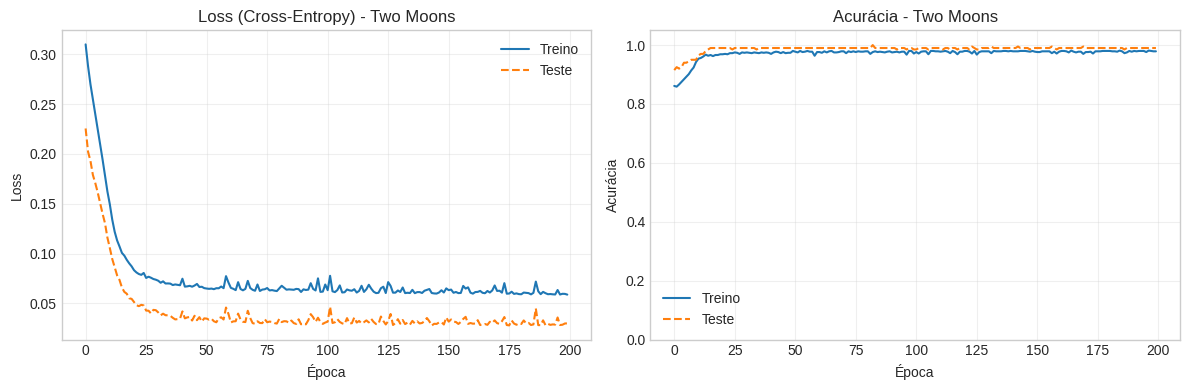

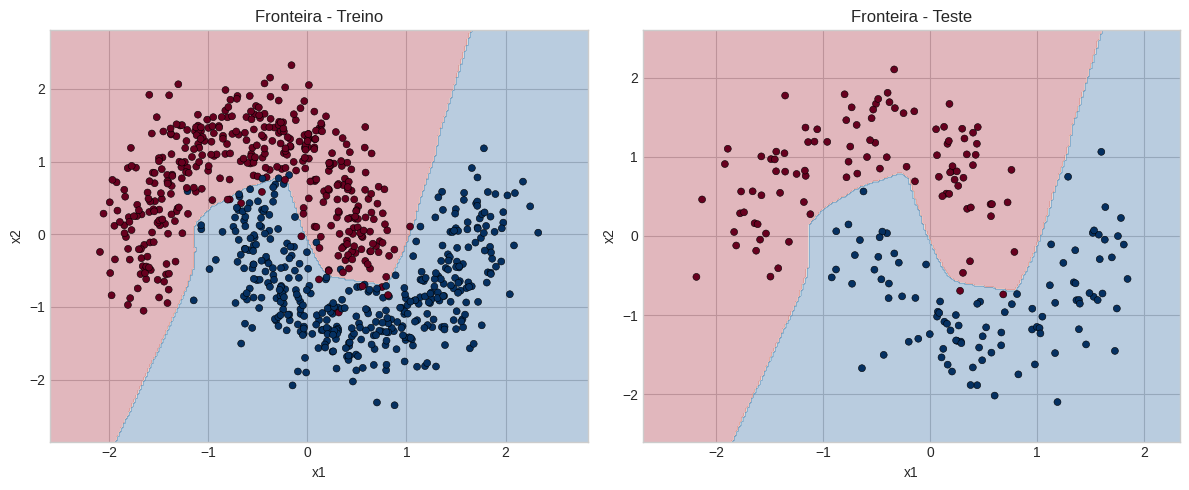

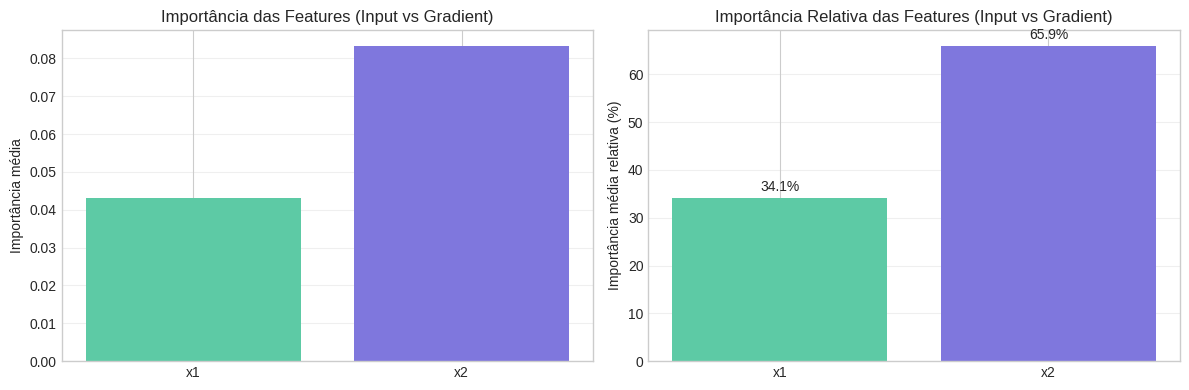

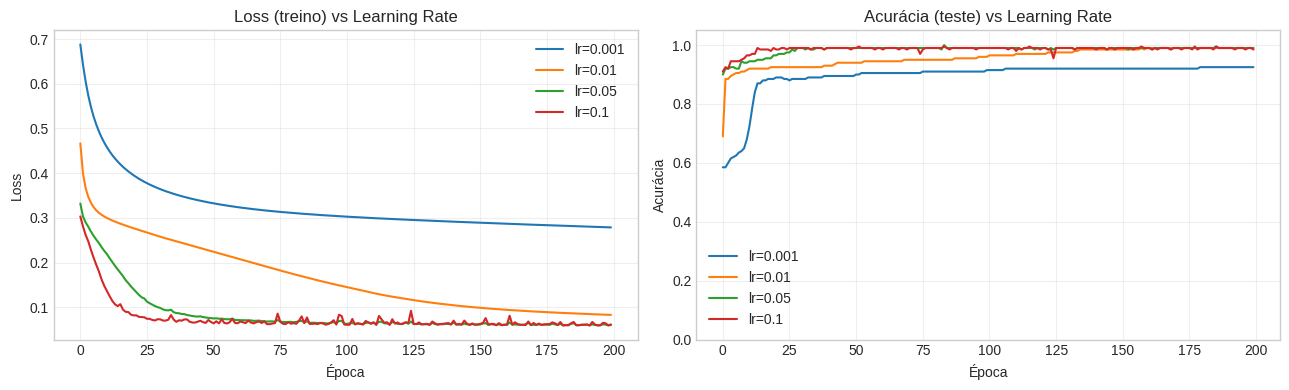

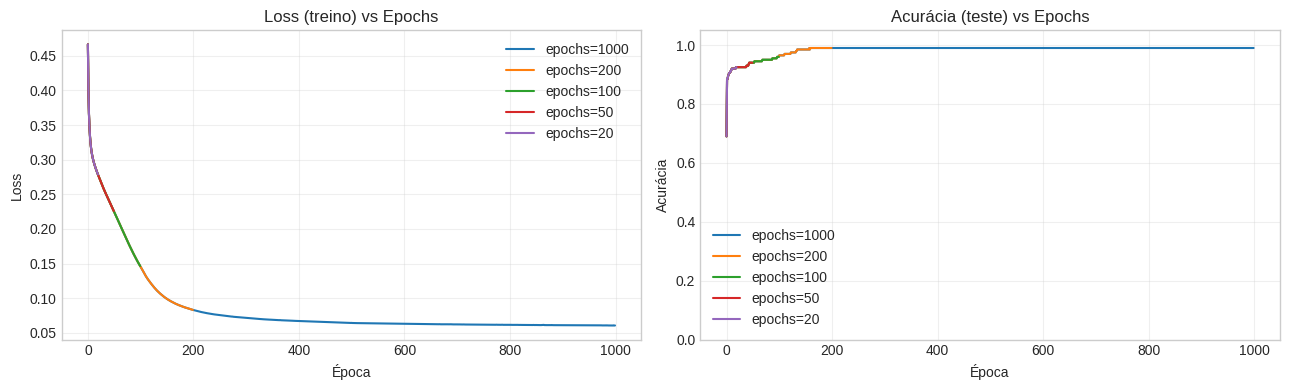

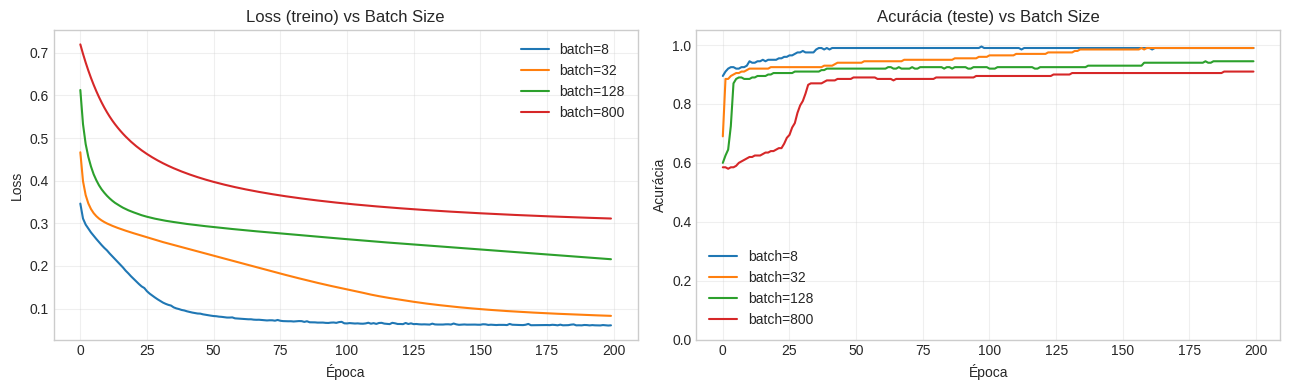

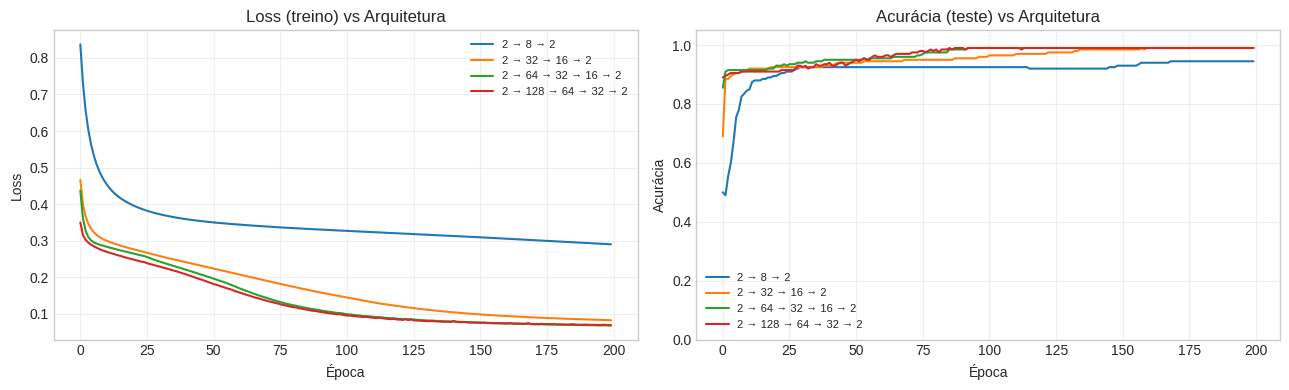

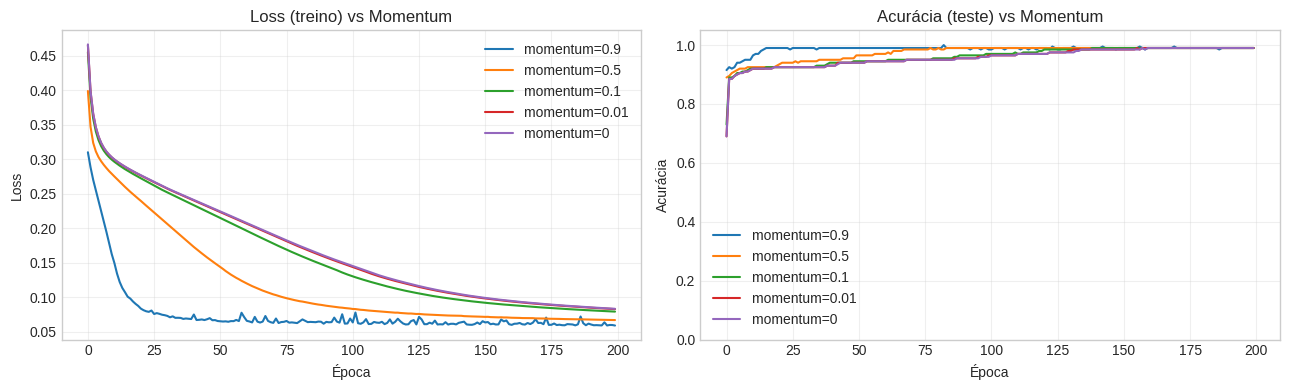

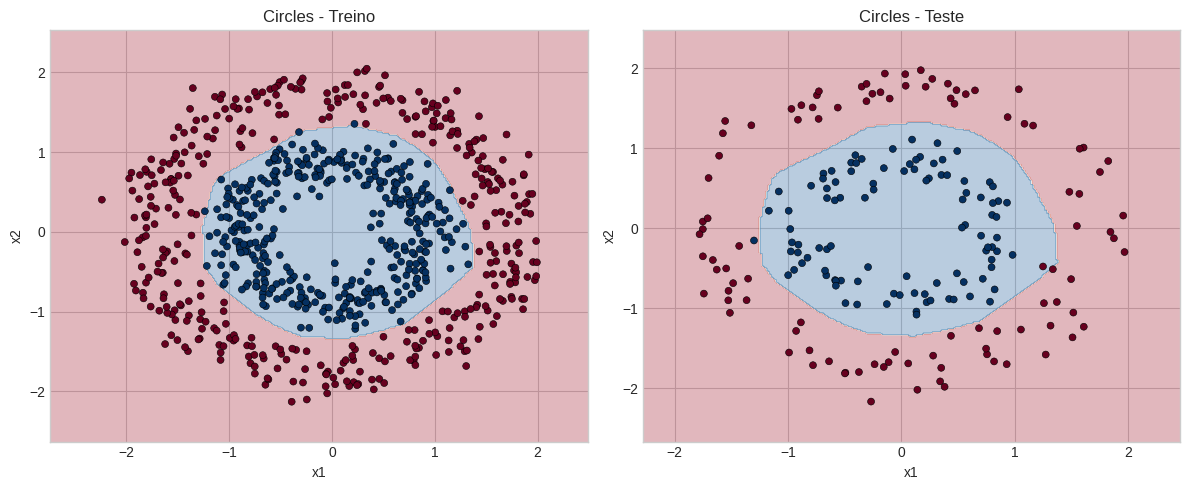

In [14]:
plt.style.use("seaborn-v0_8-whitegrid")

# Dataset
print("=" * 55)
print("  TP3 - Aplicação 2: Dataset Sintético (Two Moons)")
print("=" * 55)

X_train, X_test, y_train, y_test, scaler = load_dataset(
    kind="moons", n_samples=1000, noise=0.2
)
print(f"Treino: {X_train.shape}  |  Teste: {X_test.shape}\n")

# Treinamento principal (Two Moons)
print("Treinamento principal (Two Moons)")
layer_dims = [2, 32, 16, 2]
params, history, n_layers = train(
    X_train, y_train, X_test, y_test,
    layer_dims=layer_dims,
    lr=0.01, epochs=200, batch_size=32,
    momentum=0.9, init="he"
)

final_acc = history["acc_test"][-1]*100
print(f"\nAcurácia final no teste: {final_acc:.2f}%")

# Curvas de treinamento
fig_hist = plot_history(history, title_suffix="- Two Moons")
fig_hist.savefig("curvas_treinamento.png", dpi=150, bbox_inches="tight")
print("Salvo: curvas_treinamento.png")

# Fronteira de decisão
fig_db, axes_db = plt.subplots(1, 2, figsize=(12, 4))
plot_decision_boundary(X_train, y_train, params, n_layers,
                        title="Fronteira - Treino", ax=axes_db[0])
plot_decision_boundary(X_test,  y_test,  params, n_layers,
                        title="Fronteira - Teste",  ax=axes_db[1])
plt.tight_layout()
fig_db.savefig("fronteira_decisao.png", dpi=150, bbox_inches="tight")
print("Salvo: fronteira_decisao.png")

# Interpretabilidade
fig_imp = plot_gradient_importance(
    X_test, y_test, params, n_layers,
    feature_names=["x1", "x2"]
)
fig_imp.savefig("importancia_features.png", dpi=150, bbox_inches="tight")
print("Salvo: importancia_features.png")

fig_imp2 = plot_spatial_gradient_importance(X_test, y_test, params, n_layers)
fig_imp2.savefig("importancia_features2.png", dpi=150, bbox_inches="tight")
print("Salvo: importancia_features2.png")

# Experimentos
print("\nExperimento: Learning Rate")
fig_lr = experiment_lr(
    X_train, y_train, X_test, y_test,
    learning_rates=[0.001, 0.01, 0.05, 0.1]
)
fig_lr.savefig("exp_learning_rate.png", dpi=150, bbox_inches="tight")
print("Salvo: exp_learning_rate.png")

print("\nExperimento: Epochs")
fig_lr = experiment_epochs(
    X_train, y_train, X_test, y_test,
    epochs=[1000, 200, 100, 50, 20]
)
fig_lr.savefig("exp_epochs.png", dpi=150, bbox_inches="tight")
print("Salvo: exp_epochs.png")

print("\nExperimento: Batch Size")
fig_bs = experiment_batch(
    X_train, y_train, X_test, y_test,
    batch_sizes=[8, 32, 128, 800]
)
fig_bs.savefig("exp_batch_size.png", dpi=150, bbox_inches="tight")
print("Salvo: exp_batch_size.png")

print("\nExperimento: Arquitetura")
fig_arch = experiment_architecture(
    X_train, y_train, X_test, y_test,
    architectures=[[8], [32, 16], [64, 32, 16], [128, 64, 32]]
)
fig_arch.savefig("exp_arquitetura.png", dpi=150, bbox_inches="tight")
print("Salvo: exp_arquitetura.png")

print("\nExperimento: Momentum")
fig_mom = experiment_momentum(
    X_train, y_train, X_test, y_test,
    momentuns=[0.9, 0.5, 0.1, 0.01, 0]
)
fig_mom.savefig("exp_momentum.png", dpi=150, bbox_inches="tight")
print("Salvo: exp_momentum.png")

print("\nExperimento: Inicializações")
fig_init = experiment_init(
    X_train, y_train, X_test, y_test
)
fig_init.savefig("exp_initialization.png", dpi=150, bbox_inches="tight")
print("Salvo: exp_initialization.png")

# Treinamento secundário (Circles)
print("\nTreinamento secundário (Circles)")
X_tr_c, X_te_c, y_tr_c, y_te_c, _ = load_dataset(
    kind="circles", n_samples=1000, noise=0.1
)
params_c, history_c, nl_c = train(
    X_tr_c, y_tr_c, X_te_c, y_te_c,
    layer_dims=[2, 32, 16, 2],
    lr=0.01, epochs=200, batch_size=32, momentum=0.9
)

fig_hist_c = plot_history(history_c, title_suffix="- Circles")
fig_hist_c.savefig("treinamento_circles.png", dpi=150, bbox_inches="tight")
print("Salvo: treinamento_circles.png")

fig_c, axes_c = plt.subplots(1, 2, figsize=(12, 4))
plot_decision_boundary(X_tr_c, y_tr_c, params_c, nl_c,
                        title="Circles - Treino", ax=axes_c[0])
plot_decision_boundary(X_te_c, y_te_c, params_c, nl_c,
                        title="Circles - Teste",  ax=axes_c[1])
plt.tight_layout()
fig_c.savefig("fronteira_circles.png", dpi=150, bbox_inches="tight")
print("Salvo: fronteira_circles.png")
